#### Confidence Intervals, Standard Error (SE), Margin of Error (MOE) — with `statsmodels`

This notebook teaches **estimation + uncertainty** for:

- Mean: estimate, **SE**, **MOE**, **CI**
- Proportion: estimate, **SE**, **MOE**, **CI**
- Difference between two means (Welch) + CI
- Difference between two proportions + CI

We will use the **RAND Health Insurance Experiment** dataset shipped with `statsmodels` (`randhie`).
It’s a classic, policy-relevant dataset about health care use and insurance design.  Each row is a person and columns describe their health, insurance assignment, and how much care they used.”

##### Rows
* **Each row = one individual** enrolled in the RAND Health Insurance Experiment.
* Observations correspond to **people**, not visits.
* Measures summarize each person’s **health status, insurance plan, and medical utilization** over the study period.


Number of observations - 20,190
Number of variables - 10
##### Variable name definitions::
    mdvis   - Number of outpatient visits to an MD
    lncoins - ln(coinsurance + 1), 0 <= coninsurance <= 100
    idp     - 1 if individual deductible plan, 0 otherwise
    lpi     - ln(max(1, annual participation incentive payment))
    fmde    - 0 if idp = 1; ln(max(1, MDE/(0.01 coinsurance))) otherwise
    physlm  - 1 if the person has a physical limitation
    disea   - number of chronic diseases
    hlthg   - 1 if self-rated health is good
    hlthf   - 1 if self-rated health is fair
    hlthp   - 1 if self-rated health is poor
    (Omitted category is excellent self-rated health)

##### Major Columns you will use:
Health care use `mdvis`, Health status`hlthp`, and - Insurance / treatment assignment `idp`

In [23]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from statsmodels.stats.proportion import proportion_confint, confint_proportions_2indep

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Load data (bundled with statsmodels)
df = sm.datasets.randhie.load_pandas().data.copy()

df.head()

,mdvis,lncoins,idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
0,0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
1,2,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
2,0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
3,0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0
4,0,4.61512,1,6.907755,0.0,0.0,13.73189,1,0,0


##### Dataset quick tour

Key variables we’ll use:

- `mdvis`: number of outpatient/doctor visits (count-like, but we treat it as a numeric outcome)
- `hlthp`: indicator for "poor health" (binary: 1 = poor, 0 = not poor)
- `idp`: indicator for insurance plan type (binary group label; we’ll use it to compare groups)


In [24]:
df[["mdvis", "hlthp", "idp"]].describe(include="all")


,mdvis,hlthp,idp
count,20190.000000,20190.000000,20190.000000
mean,2.860426,0.014958,0.259980
std,4.504365,0.121387,0.438634
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,4.000000,0.000000,1.000000
max,77.000000,1.000000,1.000000


##### ✅ Task for students:
Drop missing of mdvis column (doctor visits) -> cast it to float ->  and convert the column to a numpy array 

In [25]:
# Your answer here
x = df["mdvis"].dropna().astype(float).to_numpy()

##### ✅ Task for students: Mean estimation (SE, MOE, CI)

Apply DescrStatsW on `mdvis` (doctor visits) to compute:

1) the estimated mean  
2) the standard error of the mean (**SE**)

In [26]:
# mean + SE using DescrStatsW
ds = DescrStatsW(x)
mean_hat = ds.mean # sample mean 
se_mean = ds.std_mean # standard error

##### ✅ Task for students: Mean estimation (SE, MOE, CI)

Apply zconfint_mean on `mdvis` (doctor visits) to compute:

1) the **margin of error** of our mean estimation
2) a **95% confidence interval** for the mean
3) introduce the results as a simple pandas Dataframe

In [27]:
# 95% CI using normal approximation (z), alpha=0.05
ci_low, ci_high = ds.zconfint_mean(alpha=0.05)

In [28]:
# margin of error (normal/z): symmetric half-width (or z*SE)
moe = ci_high - mean_hat  # same as mean_hat - ci_low, and same as (ci_high-ci_low)/2

pd.DataFrame([{
    "n": int(ds.nobs),
    "mean": float(mean_hat),
    "se_mean": float(se_mean),
    "moe": float(moe),
    "ci_low": float(ci_low),
    "ci_high": float(ci_high),
}])

,n,mean,se_mean,moe,ci_low,ci_high
0,20190,2.860426,0.0317,0.062132,2.798294,2.922558


##### ✅ Task for students: Effect of sample size on confidence intervals

In this task, you will study how **sample size affects uncertainty** when estimating a mean.

Using the variable `mdvis` (doctor visits):

1. Draw random samples of different sizes (for example: n = 25, 50, 100, 250, 500).
2. For each sample:
   - compute the sample mean
   - compute the standard error using `DescrStatsW`
   - compute a 95% confidence interval using `zconfint_mean`
3. Create a plot showing the **mean and its confidence interval** for each sample size.

**Question to answer:**  
How does the width of the confidence interval change as the sample size increases?


In [29]:
x_all = df["mdvis"].dropna().astype(float).to_numpy()


# Try different sample sizes (adjust/add more if you like)
ns = [25, 50, 100, 250, 500, 1000]

rng = np.random.default_rng(42)  # reproducible
rows = []

for n in ns:

    x = rng.choice(x_all, size=n, replace=False)  # sample without replacement

    # Your code here
    ds = DescrStatsW(x)

    mean_hat = ds.mean
    se_mean = ds.std_mean
    ci_low, ci_high = ds.zconfint_mean(alpha=0.05)
    moe = ci_high - mean_hat  # symmetric for z-CI

    rows.append({
        "n": n,
        "mean": float(mean_hat),
        "se_mean": float(se_mean),
        "moe": float(moe),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
    })

res = pd.DataFrame(rows).sort_values("n")
res

,n,mean,se_mean,moe,ci_low,ci_high
0,25,3.960,1.604660,3.145076,0.814924,7.105076
1,50,3.420,0.774644,1.518275,1.901725,4.938275
2,100,3.170,0.538433,1.055309,2.114691,4.225309
3,250,3.344,0.349283,0.684582,2.659418,4.028582
4,500,2.396,0.150372,0.294723,2.101277,2.690723
5,1000,2.991,0.147053,0.288218,2.702782,3.279218


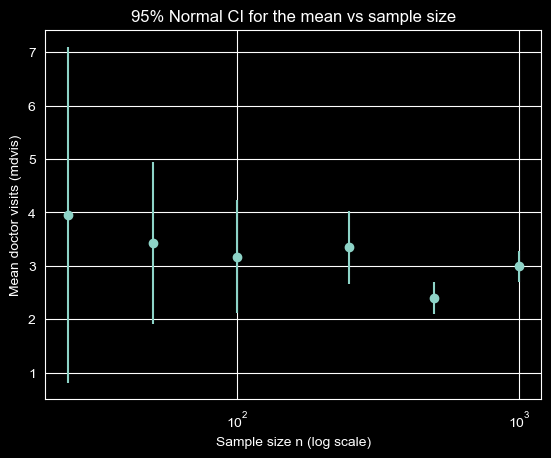

In [30]:
import matplotlib.pyplot as plt

# Visualize how CI width shrinks as n grows
plt.figure()

# Your code here
plt.errorbar(
    x=res["n"],
    y=res["mean"],
    yerr=[res["mean"] - res["ci_low"], res["ci_high"] - res["mean"]],
    fmt="o",
)


plt.xscale("log")
plt.xlabel("Sample size n (log scale)")
plt.ylabel("Mean doctor visits (mdvis)")
plt.title("95% Normal CI for the mean vs sample size")
plt.show()

##### ✅ Task for students: Visualizing the margin of error as sample size grows

The margin of error (MOE) summarizes the uncertainty of an estimate.

1. Using the same samples as in Task 3, change the code above to Compute the margin of error for each sample size  
   (MOE = upper CI bound − mean).
   
2. Create a plot of **MOE versus sample size**.

4. Use a logarithmic scale on the x-axis if helpful.

**Questions to answer:** 

- What happens to the MOE as `n` increases?  
- Does the pattern match the theoretical relationship MOE ∝ 1 / √n?


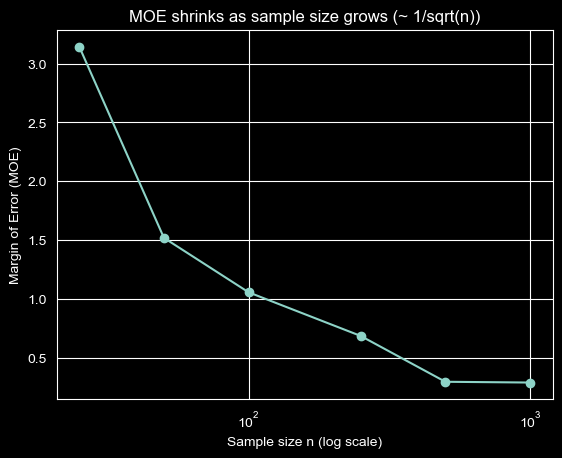

In [31]:
# Visualize MOE directly vs n
plt.figure()

# Your code here
plt.plot(res["n"], res["moe"], marker="o")

plt.xscale("log")
plt.xlabel("Sample size n (log scale)")
plt.ylabel("Margin of Error (MOE)")
plt.title("MOE shrinks as sample size grows (~ 1/sqrt(n))")
plt.show()


#### ✅ Task for studens: Sampling variability at a fixed sample size

In this task, you will study how **confidence intervals move across samples** when the sample size is fixed.

Using `mdvis`:

1. Fix the sample size at a moderate value (e.g., n = 100).
2. Draw many random samples of this size (e.g., 30–50 samples).
3. For each sample:
   - compute the sample mean
   - compute a 95% confidence interval using `zconfint_mean`
4. Plot all confidence intervals on the same figure (one horizontal line per sample).

**Questions to answer:**
- Do all confidence intervals look the same?
- Why do the centers (means) change even though `n` is fixed?
- What does this tell you about the concept of *sampling variability*?


In [32]:
n_fixed = 100
B = 40  # number of repeated samples

cis = []
for i in range(B):
    x = rng.choice(x_all, size=n_fixed, replace=False)

    # Your code here
    ds = DescrStatsW(x)
    mean_hat = ds.mean
    ci_low, ci_high = ds.zconfint_mean(alpha=0.05)
    
    cis.append({"rep": i + 1, "mean": float(mean_hat), "ci_low": float(ci_low), "ci_high": float(ci_high)})

res3 = pd.DataFrame(cis)
res3.head()


,rep,mean,ci_low,ci_high
0,1,4.02,2.256807,5.783193
1,2,2.78,2.092202,3.467798
2,3,2.61,1.997197,3.222803
3,4,2.70,1.995525,3.404475
4,5,2.38,1.658501,3.101499


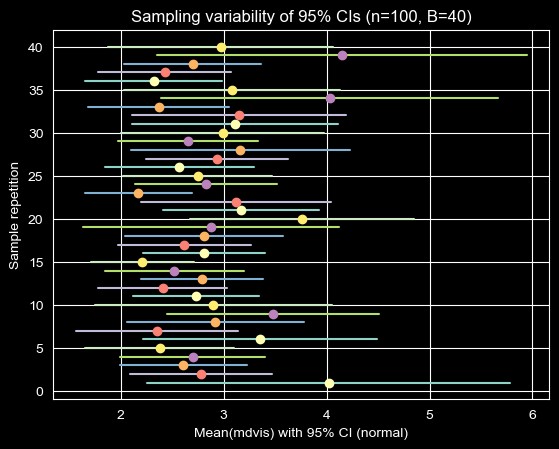

In [33]:
plt.figure()
for _, r in res3.iterrows():
    plt.plot([r["ci_low"], r["ci_high"]], [r["rep"], r["rep"]])      # CI line
    plt.plot(r["mean"], r["rep"], marker="o")                        # mean point

plt.xlabel("Mean(mdvis) with 95% CI (normal)")
plt.ylabel("Sample repetition")
plt.title(f"Sampling variability of 95% CIs (n={n_fixed}, B={B})")
plt.show()


#### ✅ Task for students: Mean estimation (SE, MOE, CI)
Drop missing of hlthp column (doctor visits) and convert the column to a numpy array  s

In [34]:
s = df["hlthp"].dropna().astype(int).to_numpy()

##### ✅ Task for students Proportion estimation (SE, MOE, CI)

We’ll use `hlthp` as an indicator for “poor health” (1 = poor health, 0 = not poor).

Compute:

1) the sample proportion in poor health  
2) its SE (for intuition)  
3) a **95% confidence interval** using the **normal** method  of  proportion_confint method form statsmodels
4) the MOE

Show the results in a table and **state the CI method you used**.


In [35]:
# Your code here
# 1) sample proportion
k = int(s.sum())          # successes (poor health)
n = int(s.shape[0])       # total
p_hat = k / n

# 2) SE for intuition (normal/Wald)
se_p = np.sqrt(p_hat * (1 - p_hat) / n)

# 3) 95% CI using normal approximation (Wald)
ci_low, ci_high = proportion_confint(count=k, nobs=n, alpha=0.05, method="normal")

# 4) MOE (normal CI is symmetric)
moe = ci_high - p_hat  # same as p_hat - ci_low



pd.DataFrame([{
    "n": n,
    "count_success": k,
    "p_hat": float(p_hat),
    "se_p_hat": float(se_p),
    "ci_low": float(ci_low),
    "ci_high": float(ci_high),
    "moe": float(moe),
    "ci_method": "normal (Wald)",
}])

,n,count_success,p_hat,se_p_hat,ci_low,ci_high,moe,ci_method
0,20190,302,0.014958,0.000854,0.013284,0.016632,0.001674,normal (Wald)


##### ✅ Task for students: Difference between two means (standard normal method)

We will compare the average number of doctor visits (`mdvis`) between two independent groups:

- Group 1: individuals with `idp == 1` # reporting poor health status
- Group 0: individuals with `idp == 0`

Using the **standard two-sample difference-in-means approach** taught in class:

1) Compute the estimated difference in means  
$\widehat{\Delta} = \bar{x}_1 - \bar{x}_0\$

2) Compute the standard error  
$SE(\widehat{\Delta}) = \sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}}$

3) Construct a **95% confidence interval** using the normal approximation  
$\widehat{\Delta} \pm 1.96 \times SE(\widehat{\Delta})$

4) Compute the **margin of error**  
$MOE = 1.96 \times SE(\widehat{\Delta})$

Finally, write **one sentence in plain language** stating whether the data suggest a difference in mean doctor visits between the two groups.


In [36]:
# Split into groups 
g1 = df.loc[df["idp"] == 1, "mdvis"].dropna().astype(float).to_numpy()
g0 = df.loc[df["idp"] == 0, "mdvis"].dropna().astype(float).to_numpy()

# Sample sizes
n1, n0 = len(g1), len(g0)

# Sample means
xbar1, xbar0 = g1.mean(), g0.mean()

# Sample standard deviations (ddof=1 for sample SD)
s1, s0 = g1.std(ddof=1), g0.std(ddof=1)

# 1) Difference in means (Group1 - Group0)
diff_hat = xbar1 - xbar0

# 2) Standard error
se_diff = np.sqrt((s1**2) / n1 + (s0**2) / n0)

# 3) 95% CI using normal approximation (z = 1.96)
z = 1.96
ci_low = diff_hat - z * se_diff
ci_high = diff_hat + z * se_diff

# 4) Margin of error
moe = z * se_diff

# Results table
out = pd.DataFrame([{
    "n_group1": n1,
    "n_group0": n0,
    "mean_group1": xbar1,
    "mean_group0": xbar0,
    "sd_group1": s1,
    "sd_group0": s0,
    "diff_mean (g1-g0)": diff_hat,
    "se_diff": se_diff,
    "moe": moe,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "ci_method": "normal (z=1.96)",
}])

out

,n_group1,n_group0,mean_group1,mean_group0,sd_group1,sd_group0,diff_mean (g1-g0),se_diff,moe,ci_low,ci_high,ci_method
0,5249,14941,2.473233,2.996453,4.139583,4.618127,-0.52322,0.068499,0.134257,-0.657477,-0.388962,normal (z=1.96)


In [37]:
diff_hat

np.float64(-0.5232197172471453)

In [38]:
# Your answer here:
conclusion =  (f"Group 1 (self-rated health is poor) has fewer doctor visits (about {diff_hat:.3f}) on average than Group 0 "
    f"(95% CI  is entirely negative [{ci_low:.3f}, {ci_high:.3f}]), suggesting a difference between groups.")
conclusion

'Group 1 (self-rated health is poor) has fewer doctor visits (about -0.523) on average than Group 0 (95% CI  is entirely negative [-0.657, -0.389]), suggesting a difference between groups.'

##### ✅ Task for students:  Difference between two proportions (group comparison)

Now compare the proportion in poor health (`hlthp == 1`) between `idp` groups.

Compute the difference in proportions:

- Group 1: `idp == 1`
- Group 0: `idp == 0`

Use a modern two-proportion CI method via `statsmodels` (`method="score"` is a good default) and report:

1) p̂1 and p̂0  
2) difference p̂1 − p̂0  
3) a 95% CI for the difference  
4) MOE  

Then interpret whether the interval suggests a clear difference.


In [39]:
# Split into groups (drop missing)
g1 = df.loc[df["idp"] == 1, "hlthp"].dropna().astype(int).to_numpy()
g0 = df.loc[df["idp"] == 0, "hlthp"].dropna().astype(int).to_numpy()

# Counts and sample sizes
k1, n1 = int(g1.sum()), int(len(g1))
k0, n0 = int(g0.sum()), int(len(g0))

# 1) Sample proportions
p1_hat = k1 / n1
p0_hat = k0 / n0

# 2) Difference in proportions
diff_hat = p1_hat - p0_hat

# 3) Standard error (normal/Wald)
se_diff = np.sqrt(p1_hat * (1 - p1_hat) / n1 + p0_hat * (1 - p0_hat) / n0)

# 4) 95% CI using normal approximation
z = 1.96
ci_low = diff_hat - z * se_diff
ci_high = diff_hat + z * se_diff

# 5) Margin of error
moe = z * se_diff

# Results table
out = pd.DataFrame([{
    "n1": n1, "k1": k1, "p1_hat": p1_hat,
    "n0": n0, "k0": k0, "p0_hat": p0_hat,
    "diff_hat (p1-p0)": diff_hat,
    "se_diff": se_diff,
    "moe": moe,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "ci_method": "normal (z=1.96)",
}])

In [40]:
# Interpretation in one sentence
Conclusion = (
    f"The estimated difference in poor-health proportions is {diff_hat:.4f} "
    f"(95% CI [{ci_low:.4f}, {ci_high:.4f}]); "
    f"The data suggests no clear difference between groups."
)
    
Conclusion

'The estimated difference in poor-health proportions is -0.0004 (95% CI [-0.0042, 0.0034]); The data suggests no clear difference between groups.'

## Wrap-up checklist

By the end, you should be able to:

- Compute mean SE/MOE/CI using `DescrStatsW`
- Compute proportion CI using `proportion_confint` 
- Compare two means with CI using `CompareMeans`
- Compare two proportions with a modern CI using `confint_proportions_2indep`